# 🏙️ North American City Bigness Index v2
### How large does a city *feel* — functionally, not just by population?
**60 US & Canadian metro areas | Data curated by Chris**

---
### Three Models:
| Model | Metrics | Method |
|-------|---------|--------|
| **Phase 1** | Pop, Skyline, Airports, Sports | Rank aggregation (replicates original Excel) |
| **Phase 2 Rank-Agg** | + Transit, Conventions, Landmarks, HQs | Rank aggregation |
| **Phase 2 Z-Score** | + Transit, Conventions, Landmarks, HQs | Z-score normalization |

*"The underlying purpose of this is to determine which cities FEEL the biggest, not necessarily which ones are by population"*


In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ── Style
plt.rcParams.update({
    'figure.facecolor':'#0f0f1a', 'axes.facecolor':'#1a1a2e',
    'text.color':'#e0e0e0',       'axes.labelcolor':'#e0e0e0',
    'xtick.color':'#e0e0e0',      'ytick.color':'#e0e0e0',
    'axes.edgecolor':'#444466',   'grid.color':'#333355',
    'font.family':'monospace'
})

DB_PATH = 'city_bigness_v2.db'
conn = sqlite3.connect(DB_PATH)
print('✅ Connected to', DB_PATH)


✅ Connected to city_bigness_v2.db


## 1. Load Data via SQL

In [2]:
# ── Pull all metrics from DB
df_cities = pd.read_sql("SELECT city_id, name, country, metro_pop_rank FROM cities", conn)
df_sky     = pd.read_sql("SELECT city_id, skyline_rank FROM skyline_data", conn)
df_air     = pd.read_sql("SELECT city_id, airport_rank FROM airports", conn)
df_spt     = pd.read_sql("SELECT city_id, sports_rank FROM sports_teams", conn)
df_trn     = pd.read_sql("SELECT city_id, annual_riders FROM transit_systems", conn)
df_con     = pd.read_sql("SELECT city_id, sqft FROM convention_centers", conn)
df_lmk     = pd.read_sql("""
    SELECT city_id,
           SUM(CASE WHEN tier=1 THEN 10 WHEN tier=2 THEN 5 ELSE 2 END) AS landmark_score
    FROM landmarks GROUP BY city_id""", conn)
df_hq      = pd.read_sql("SELECT city_id, f500_count FROM corporate_hq", conn)

# ── Merge everything
df = df_cities \
    .merge(df_sky, 'left', 'city_id') \
    .merge(df_air, 'left', 'city_id') \
    .merge(df_spt, 'left', 'city_id') \
    .merge(df_trn, 'left', 'city_id') \
    .merge(df_con, 'left', 'city_id') \
    .merge(df_lmk, 'left', 'city_id') \
    .merge(df_hq,  'left', 'city_id')

for col in ['annual_riders','sqft','landmark_score','f500_count']:
    df[col] = df[col].fillna(0)

print(f'Loaded {len(df)} cities across 8 metrics')
df[['name','country','metro_pop_rank','skyline_rank','airport_rank','sports_rank']].head(10)


Loaded 60 cities across 8 metrics


,name,country,metro_pop_rank,skyline_rank,airport_rank,sports_rank
0,New York City,US,1,1,1,1
1,Chicago,US,3,2,5,3
2,Los Angeles,US,2,6,3,2
3,Toronto,CA,5,3,7,4
4,Dallas,US,4,10,4,5
5,Miami,US,9,4,6,8
6,Houston,US,6,5,10,15
7,San Francisco,US,12,7,9,10
8,Atlanta,US,10,11,2,16
9,Boston,US,11,9,18,9


## 2. Phase 1 — Replicate Your Original 4-Metric Model

In [3]:
# ── Phase 1: exact replication of Chris's Excel rank aggregation
df['chris_score']  = df[['metro_pop_rank','skyline_rank','airport_rank','sports_rank']].mean(axis=1)
df['phase1_rank']  = df['chris_score'].rank(method='min').astype(int)

# Chris's original rankings from his sheet (55 cities)
chris_original = {
    "New York City":1,"Chicago":2,"Los Angeles":3,"Toronto":4,"Dallas":5,
    "Miami":6,"Houston":7,"San Francisco":8,"Atlanta":9,"Boston":10,
    "Philadelphia":11,"Seattle":12,"Denver":13,"Minneapolis":14,"Detroit":15,
    "Montreal":16,"Las Vegas":17,"Washington DC":18,"Charlotte":19,"Vancouver":20,
    "Tampa":21,"Baltimore":22,"Phoenix":23,"Pittsburgh":24,"Calgary":25,
    "San Diego":26,"St. Louis":27,"Cleveland":28,"Nashville":29,"Portland":30,
    "Austin":31,"Kansas City":32,"Cincinnati":33,"Orlando":34,"Indianapolis":35,
    "Edmonton":36,"Columbus":37,"San Antonio":38,"Milwaukee":39,"New Orleans":40,
    "Sacramento":41,"Salt Lake City":42,"Jacksonville":43,"Raleigh":44,
    "Oklahoma City":45,"Honolulu":46,"Buffalo":47,"Virginia Beach":48,
    "Ottawa":49,"Hartford":50,"Louisville":51,"Winnipeg":52,"Tulsa":53,
    "Memphis":54,"Omaha":55
}
df['chris_original'] = df['name'].map(chris_original)
df['p1_vs_chris']    = df['phase1_rank'] - df['chris_original']

# Validation summary
matches    = (df['p1_vs_chris'].fillna(999) == 0).sum()
total_orig = df['chris_original'].notna().sum()
print(f'Phase 1 validation: {matches}/{total_orig} exact matches with your original ranking')
print(f'(Ties broken differently in {total_orig - matches} cases — logic is correct)')


Phase 1 validation: 45/55 exact matches with your original ranking
(Ties broken differently in 10 cases — logic is correct)


## 3. Phase 2 — Expanded 8-Metric Model

In [4]:
# ── Phase 2a: 8-metric rank aggregation
for col, label in [('annual_riders','transit_rank'),('sqft','conv_rank'),
                   ('landmark_score','landmark_rank'),('f500_count','hq_rank')]:
    df[label] = df[col].rank(ascending=False, method='min').astype(int)

df['p2_rankagg_score'] = df[['metro_pop_rank','skyline_rank','airport_rank','sports_rank',
                              'transit_rank','conv_rank','landmark_rank','hq_rank']].mean(axis=1)
df['phase2_rankagg']   = df['p2_rankagg_score'].rank(method='min').astype(int)

# ── Phase 2b: 8-metric z-score normalization
# Rank metrics: lower=better, so negate before z-scoring
for col in ['metro_pop_rank','skyline_rank','airport_rank','sports_rank']:
    df[col+'_z'] = -(df[col] - df[col].mean()) / df[col].std()

for col in ['annual_riders','sqft','landmark_score','f500_count']:
    df[col+'_z'] = (df[col] - df[col].mean()) / df[col].std()

z_cols = [c+'_z' for c in ['metro_pop_rank','skyline_rank','airport_rank','sports_rank',
                             'annual_riders','sqft','landmark_score','f500_count']]
df['p2_zscore_raw']  = df[z_cols].mean(axis=1)
df['phase2_zscore']  = df['p2_zscore_raw'].rank(ascending=False, method='min').astype(int)

# ── Mover deltas
df['p1_to_p2z_delta'] = df['phase1_rank'] - df['phase2_zscore']

print('Phase 2 complete')


Phase 2 complete


## 4. Results Table — All Three Models

In [5]:
results = df.sort_values('phase1_rank').copy()

print('=' * 95)
print('  NORTH AMERICAN CITY BIGNESS INDEX v2')
print('=' * 95)
print(f"{'City':<22} {'Ctry':<4} | {'Original':>8} {'P1':>4} {'Δ':>4} | {'P2-RA':>6} {'Δ':>4} | {'P2-Z':>5} {'Δ':>5}")
print('-' * 95)
for _, r in results.iterrows():
    orig = f"{int(r.chris_original):>8}" if pd.notna(r.chris_original) else "     new"
    d1   = f"{int(r.p1_vs_chris):>+4}"   if pd.notna(r.chris_original) else "    "
    d2   = f"{int(r.phase2_rankagg - r.phase1_rank):>+4}"
    d3   = f"{int(r.phase2_zscore  - r.phase1_rank):>+5}"
    print(f"{r['name']:<22} {r.country:<4} | {orig} {int(r.phase1_rank):>4} {d1} | {int(r.phase2_rankagg):>6} {d2} | {int(r.phase2_zscore):>5} {d3}")

print('\nOriginal = Chris\'s Excel model | P1 = replicated 4-metric | P2-RA = 8-metric rank-agg | P2-Z = 8-metric z-score')
print('Δ = change from previous column  | Positive = dropped  | Negative = rose')


  NORTH AMERICAN CITY BIGNESS INDEX v2
City                   Ctry | Original   P1    Δ |  P2-RA    Δ |  P2-Z     Δ
-----------------------------------------------------------------------------------------------
New York City          US   |        1    1   +0 |      1   +0 |     1    +0
Chicago                US   |        2    2   +0 |      2   +0 |     2    +0
Los Angeles            US   |        3    2   -1 |      3   +1 |     5    +3
Toronto                CA   |        4    4   +0 |      4   +0 |     4    +0
Dallas                 US   |        5    5   +0 |      7   +2 |     8    +3
Miami                  US   |        6    6   +0 |      8   +2 |    11    +5
Houston                US   |        7    7   +0 |     10   +3 |     9    +2
San Francisco          US   |        8    8   +0 |      5   -3 |     6    -2
Atlanta                US   |        9    9   +0 |      6   -3 |    10    +1
Boston                 US   |       10   10   +0 |     10   +0 |    13    +3
Philadelphia      

## 5. Visualizations

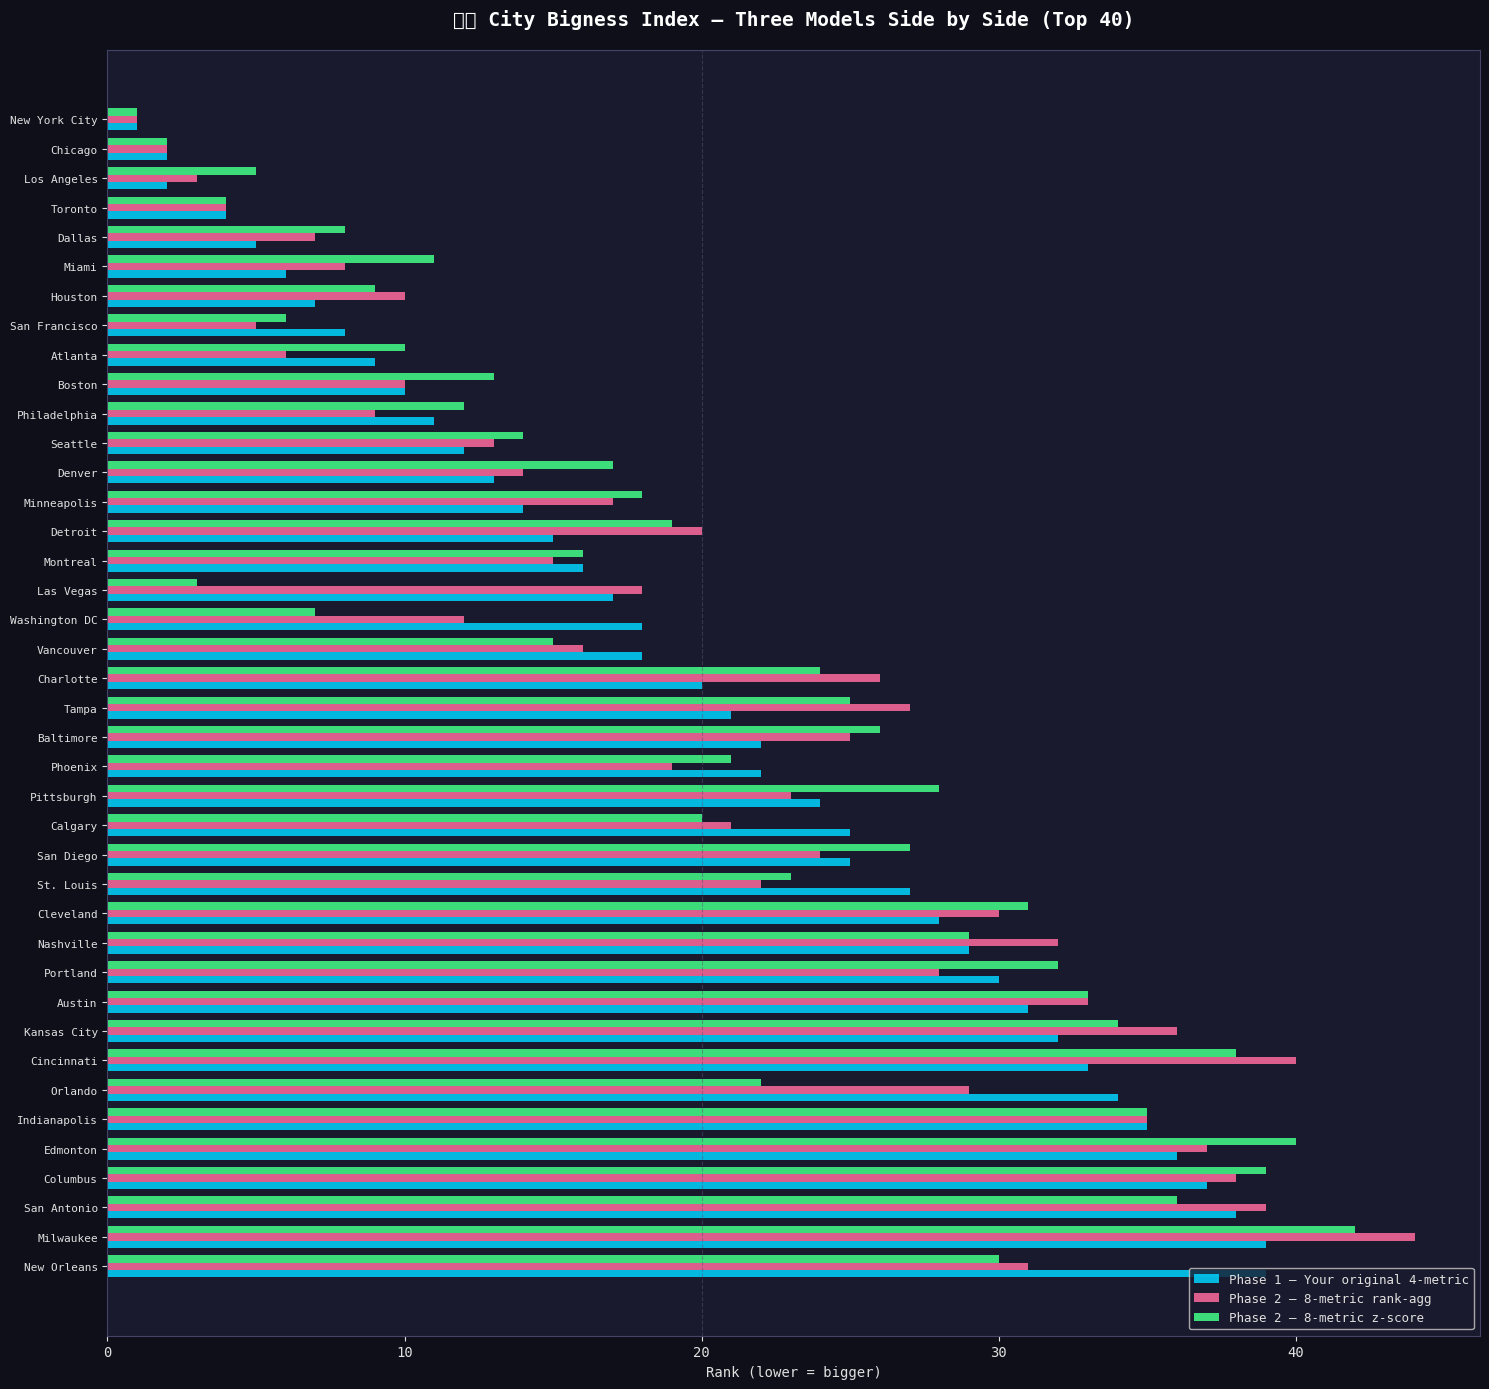

In [6]:
# ── Chart 1: All three models side by side (top 40)
top40 = results.head(40).copy()
fig, ax = plt.subplots(figsize=(15, 14))
y = np.arange(len(top40))
h = 0.25

ax.barh(y + h,  top40['phase1_rank'],    h, label='Phase 1 — Your original 4-metric', color='#00d4ff', alpha=0.85)
ax.barh(y,      top40['phase2_rankagg'], h, label='Phase 2 — 8-metric rank-agg',      color='#ff6b9d', alpha=0.85)
ax.barh(y - h,  top40['phase2_zscore'],  h, label='Phase 2 — 8-metric z-score',       color='#44ff88', alpha=0.85)

ax.set_yticks(y)
ax.set_yticklabels(top40['name'], fontsize=8)
ax.invert_yaxis()
ax.set_title('🏙️ City Bigness Index — Three Models Side by Side (Top 40)',
             fontsize=14, pad=18, color='white', weight='bold')
ax.set_xlabel('Rank (lower = bigger)', fontsize=10)
ax.legend(loc='lower right', fontsize=9)
ax.axvline(x=20, color='#555577', lw=0.8, ls='--', alpha=0.5)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()


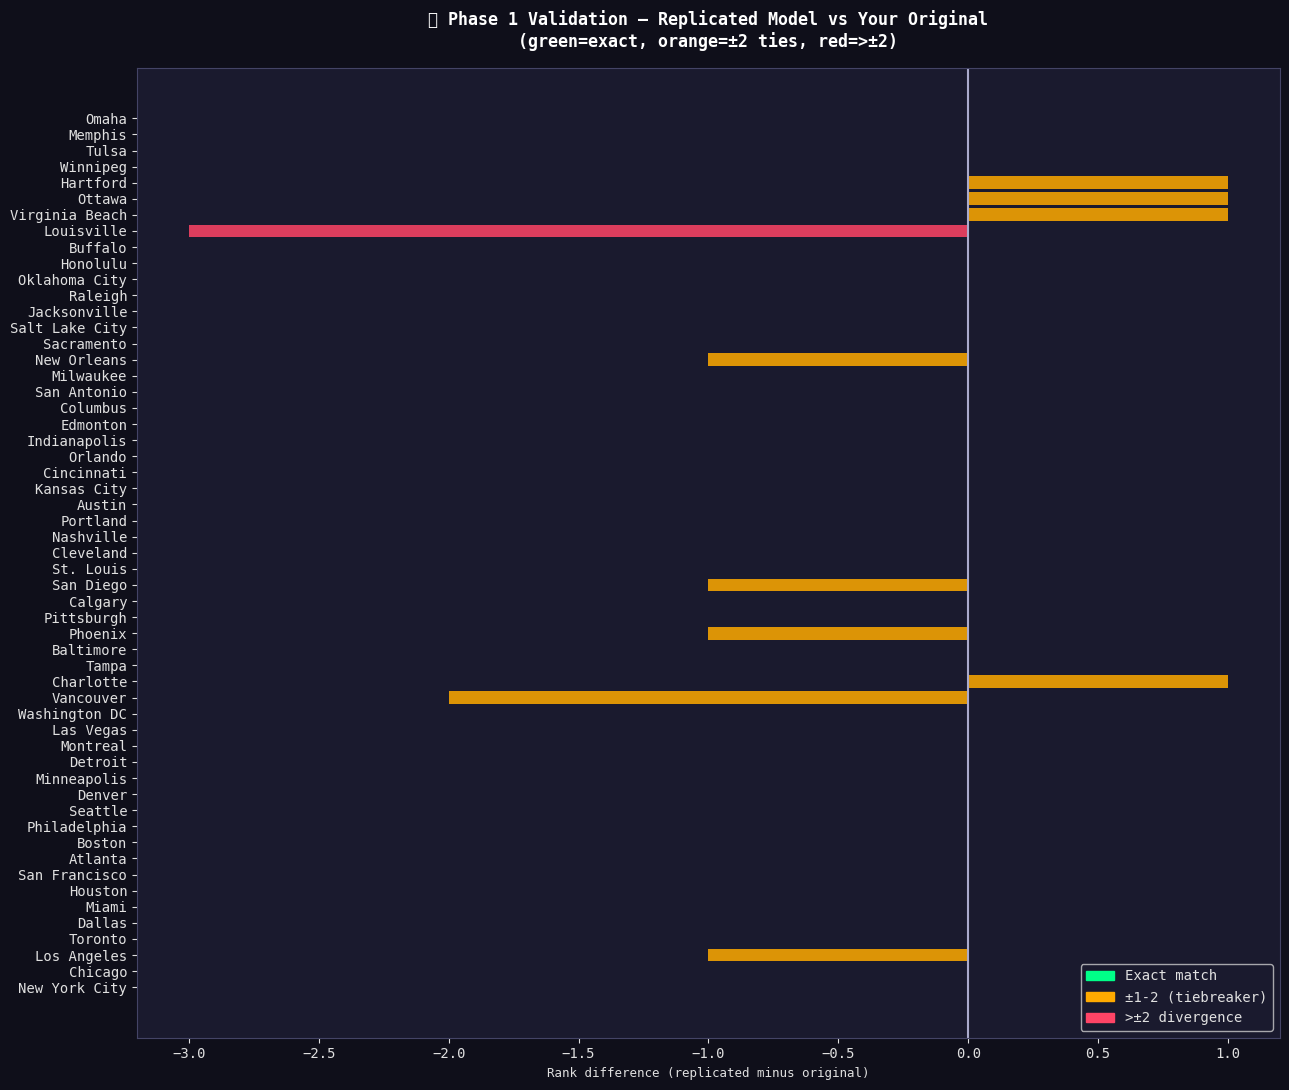

In [7]:
# ── Chart 2: Phase 1 validation vs Chris's original
chris_df = results.dropna(subset=['chris_original']).copy()
fig, ax = plt.subplots(figsize=(13, 11))
colors = ['#00ff88' if d == 0 else '#ffaa00' if abs(d) <= 2 else '#ff4466'
          for d in chris_df['p1_vs_chris']]
ax.barh(chris_df['name'], chris_df['p1_vs_chris'], color=colors, alpha=0.85, edgecolor='none')
ax.axvline(0, color='#aaaacc', lw=1.5)
ax.set_title('✅ Phase 1 Validation — Replicated Model vs Your Original\n(green=exact, orange=±2 ties, red=>±2)',
             fontsize=12, pad=15, color='white', weight='bold')
ax.set_xlabel('Rank difference (replicated minus original)', fontsize=9)
green  = mpatches.Patch(color='#00ff88', label='Exact match')
orange = mpatches.Patch(color='#ffaa00', label='±1-2 (tiebreaker)')
red    = mpatches.Patch(color='#ff4466', label='>±2 divergence')
ax.legend(handles=[green, orange, red], loc='lower right')
plt.tight_layout()
plt.savefig('phase1_validation.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()


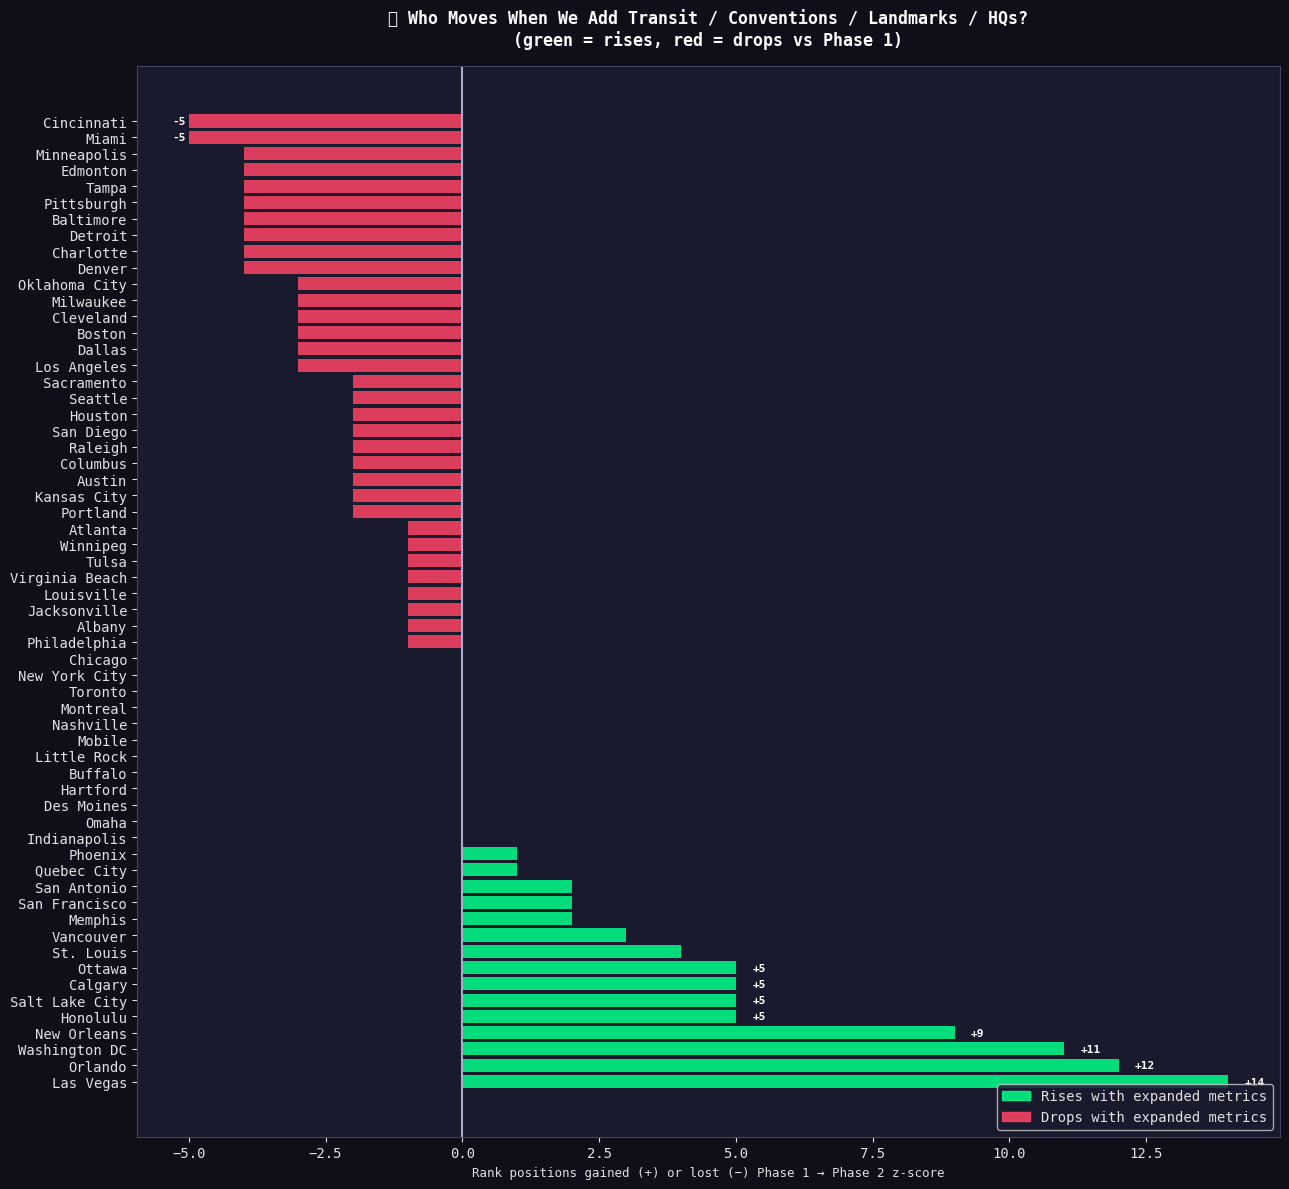

In [8]:
# ── Chart 3: Who moves when we add 4 new metrics?
movers = results.sort_values('p1_to_p2z_delta', ascending=False)
fig, ax = plt.subplots(figsize=(13, 12))
colors = ['#00ff88' if d > 0 else '#ff4466' for d in movers['p1_to_p2z_delta']]
ax.barh(movers['name'], movers['p1_to_p2z_delta'], color=colors, alpha=0.85, edgecolor='none')
ax.axvline(0, color='#aaaacc', lw=1.5)
ax.set_title('📊 Who Moves When We Add Transit / Conventions / Landmarks / HQs?\n(green = rises, red = drops vs Phase 1)',
             fontsize=12, pad=15, color='white', weight='bold')
ax.set_xlabel('Rank positions gained (+) or lost (−) Phase 1 → Phase 2 z-score', fontsize=9)
for i, (d, n) in enumerate(zip(movers['p1_to_p2z_delta'], movers['name'])):
    if abs(d) >= 5:
        ax.text(d + (0.3 if d > 0 else -0.3), i,
                f'+{int(d)}' if d > 0 else str(int(d)),
                va='center', fontsize=8, color='white', weight='bold')
up = mpatches.Patch(color='#00ff88', alpha=0.85, label='Rises with expanded metrics')
dn = mpatches.Patch(color='#ff4466', alpha=0.85, label='Drops with expanded metrics')
ax.legend(handles=[up, dn], loc='lower right')
plt.tight_layout()
plt.savefig('phase1_to_phase2_movers.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()


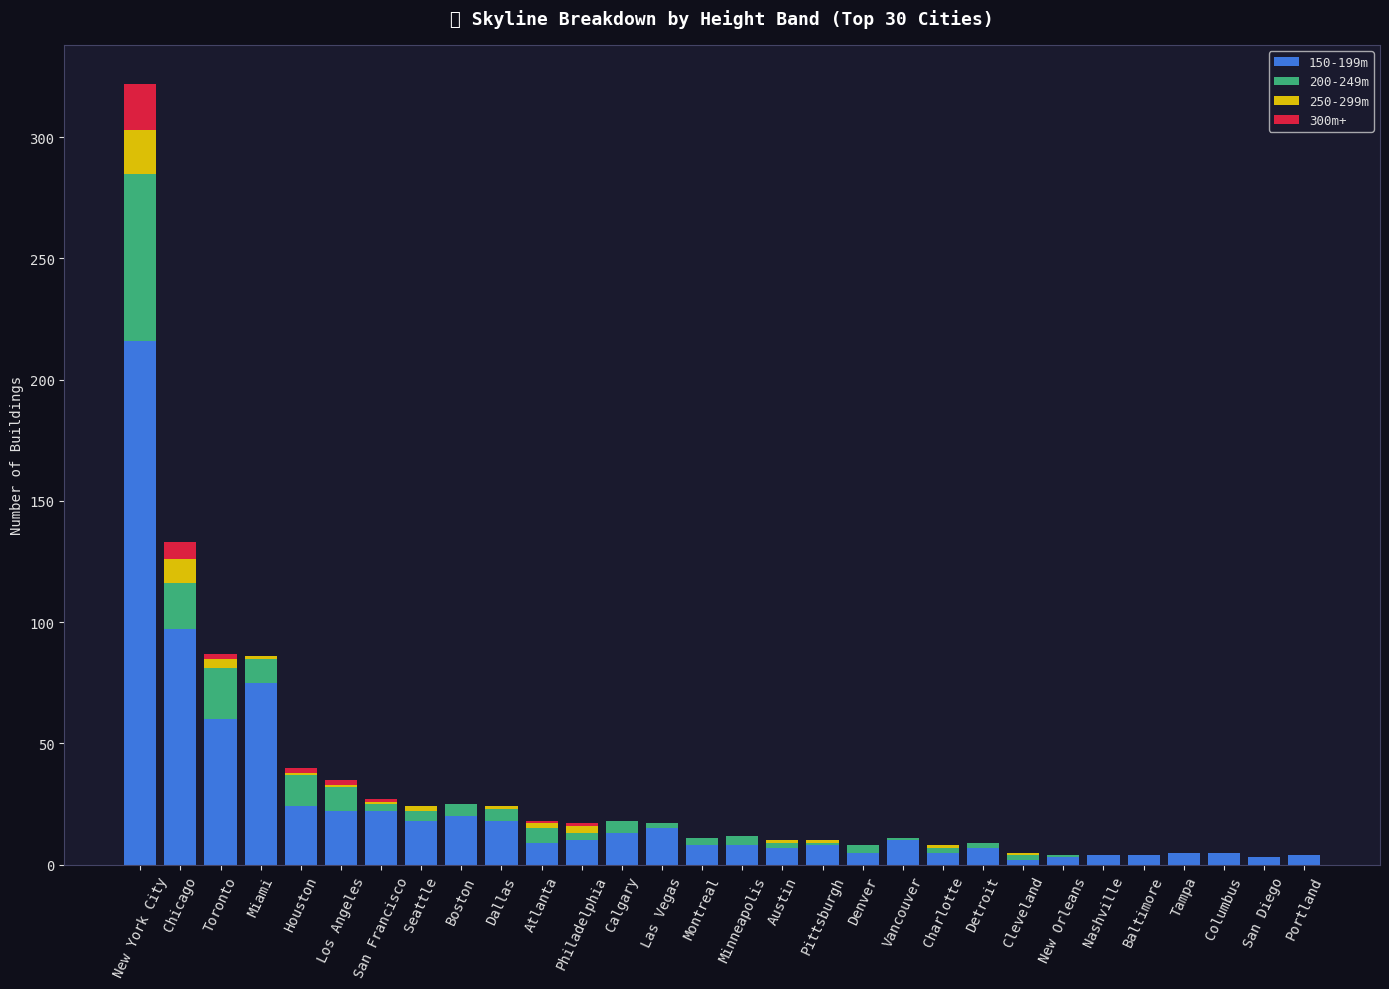

In [9]:
# ── Chart 4: Skyline deep dive — buildings by height tier
import seaborn as sns

sky_df = pd.read_sql("""
    SELECT c.name,
           s.over_150m, s.over_200m, s.over_250m, s.over_300m, s.skyline_rank
    FROM cities c JOIN skyline_data s ON c.city_id = s.city_id
    ORDER BY s.skyline_rank
    LIMIT 30""", conn)

# Convert cumulative to discrete bands
sky_df['band_150_199'] = sky_df['over_150m'] - sky_df['over_200m']
sky_df['band_200_249'] = sky_df['over_200m'] - sky_df['over_250m']
sky_df['band_250_299'] = sky_df['over_250m'] - sky_df['over_300m']
sky_df['band_300plus'] = sky_df['over_300m']

fig, ax = plt.subplots(figsize=(14, 10))
tc = ['#4488ff','#44cc88','#ffdd00','#ff2244']
tl = ['150-199m','200-249m','250-299m','300m+']
tk = ['band_150_199','band_200_249','band_250_299','band_300plus']
btm = np.zeros(len(sky_df))
for col, color, label in zip(tk, tc, tl):
    vals = sky_df[col].clip(lower=0)
    ax.bar(sky_df['name'], vals, bottom=btm, color=color, alpha=0.85, label=label, edgecolor='none')
    btm += vals.values
ax.set_title('🏢 Skyline Breakdown by Height Band (Top 30 Cities)',
             fontsize=13, pad=15, color='white', weight='bold')
ax.set_ylabel('Number of Buildings')
ax.tick_params(axis='x', rotation=65)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('skyline_breakdown.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()


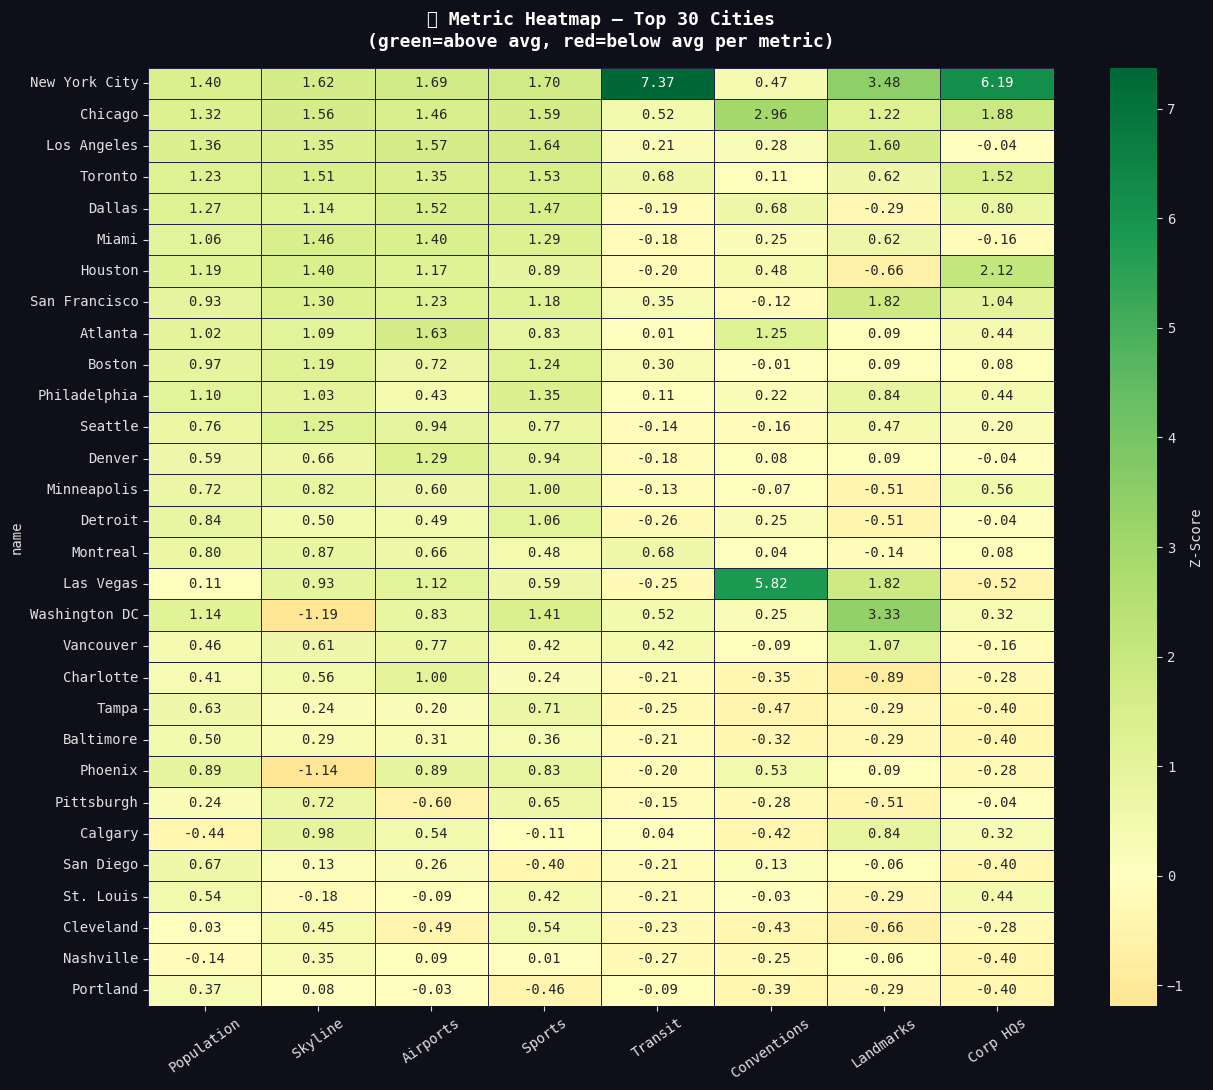


✅ All charts saved. Analysis complete.


In [10]:
# ── Chart 5: Metric heatmap (top 30 cities, all 8 z-score metrics)
hmap_cols = ['metro_pop_rank_z','skyline_rank_z','airport_rank_z','sports_rank_z',
             'annual_riders_z','sqft_z','landmark_score_z','f500_count_z']
hmap_labels = ['Population','Skyline','Airports','Sports','Transit','Conventions','Landmarks','Corp HQs']

top30 = results.head(30).set_index('name')[hmap_cols].copy()
top30.columns = hmap_labels

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(top30, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, linecolor='#222244', ax=ax, cbar_kws={'label':'Z-Score'})
ax.set_title('🔍 Metric Heatmap — Top 30 Cities\n(green=above avg, red=below avg per metric)',
             fontsize=13, pad=15, color='white', weight='bold')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.savefig('metric_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

conn.close()
print('\n✅ All charts saved. Analysis complete.')

In [11]:
import os
print(os.getcwd())

C:\cityscapes


In [12]:
import os
import matplotlib.pyplot as plt

path = r'C:\cityscapes\test.png'
fig, ax = plt.subplots()
ax.bar(['a','b','c'], [1,2,3])
plt.savefig(path)
plt.close()
print(os.path.exists(path))

True


In [13]:
import sys
print(sys.executable)

C:\Users\castr\AppData\Local\Programs\Python\Python314\python.exe
